# Lecture 13 · Causal & dilated 1-D convolution

**Goal** · build a *causal* 1-D convolution from scratch in numpy (each output sees only the current and past inputs), keep the sequence length with left-padding, then add *dilation*. Watch a single layer's receptive field grow as $(K-1)d+1$, and see a stack of dilated layers ($d=1,2,4,8$) reach a receptive field of **16** while depth grows only linearly.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(0)

## 1 · Causal conv = only current + past taps

Output position $t$ reads $x_t, x_{t-1}, \dots, x_{t-(K-1)}$ — never the future. We left-pad with $K-1$ zeros so the output has the same length as the input.

$$y_t=\sum_{k=0}^{K-1} w_k\,x_{t-k}\qquad(\text{indices below }0\text{ are the padded zeros}).$$

In [2]:
def causal_conv1d(x, w, dilation=1):
    T, K = len(x), len(w)
    pad = (K - 1) * dilation
    xp = np.concatenate([np.zeros(pad), x])       # left-pad only -> preserves length + causality
    y = np.zeros(T)
    for t in range(T):
        for k in range(K):
            y[t] += w[k] * xp[t + pad - k * dilation]   # w[0]=current tap, w[k]=k*d steps in the past
    return y

x = np.array([1., 2., 3., 4., 5.])
w = np.array([1.0, 0.5, 0.25])          # current, past-1, past-2
y = causal_conv1d(x, w)
print('x =', x)
print('y =', y, '  (len preserved:', len(y) == len(x), ')')
print('hand-check y2 = 1*3 + 0.5*2 + 0.25*1 =', 1*3 + 0.5*2 + 0.25*1)

x = [1. 2. 3. 4. 5.]
y = [1.   2.5  4.25 6.   7.75]   (len preserved: True )
hand-check y2 = 1*3 + 0.5*2 + 0.25*1 = 4.25


## 2 · Causality check

Change a *future* input and confirm earlier outputs do not move — a causal conv can never leak the future backwards.

In [3]:
x_future = x.copy()
x_future[4] = 99.0                       # perturb only the last (future-most) input
y2 = causal_conv1d(x_future, w)
print('y  (orig)   =', y)
print('y2 (x4=99)  =', y2)
print('outputs 0..3 unchanged:', np.allclose(y[:4], y2[:4]))

y  (orig)   = [1.   2.5  4.25 6.   7.75]
y2 (x4=99)  = [  1.     2.5    4.25   6.   101.75]
outputs 0..3 unchanged: True


## 3 · Dilation stretches the taps → receptive field $(K-1)d+1$

With dilation $d$ the taps skip: $y_t=\sum_k w_k\,x_{t-kd}$. One layer now covers $(K-1)d+1$ input positions.

In [4]:
K = len(w)
print(f'kernel size K = {K}')
print(' d   receptive field  (K-1)*d+1')
for d in [1, 2, 4, 8]:
    rf = (K - 1) * d + 1
    print(f' {d:>2}        {rf:>3}          {(K-1)}*{d}+1')

kernel size K = 3
 d   receptive field  (K-1)*d+1
  1          3          2*1+1
  2          5          2*2+1
  4          9          2*4+1
  8         17          2*8+1


## 4 · Stacking dilated layers → exponential receptive field

Stack layers with kernel $K=2$ and doubling dilations $1,2,4,8$. Receptive fields compose additively:

$$\text{RF}_{\text{stack}} = 1 + \sum_{\ell}(K-1)\,d_\ell = 1 + (1+2+4+8) = 16.$$

We verify the number *empirically*: feed a unit impulse at every input position and count how many of them can influence the final output (the conv is linear, so any influence shows up as a non-zero).

In [5]:
def stack_forward(x, w, dilations):
    h = x
    for d in dilations:
        h = causal_conv1d(h, w, dilation=d)
    return h

def measured_rf(T, w, dilations):
    count = 0
    for i in range(T):
        e = np.zeros(T); e[i] = 1.0                 # impulse at position i
        if abs(stack_forward(e, w, dilations)[-1]) > 1e-12:
            count += 1                              # position i reaches the last output
    return count

w2 = np.array([1.0, 1.0])                            # K=2
dils = [1, 2, 4, 8]
T = 32
formula = 1 + sum((len(w2) - 1) * d for d in dils)
print('formula  RF =', formula)
print('measured RF =', measured_rf(T, w2, dils))

formula  RF = 16
measured RF = 16


## 5 · Depth grows linearly, receptive field grows exponentially

Compare the doubling-dilation stack ($\text{RF}=2^L$ for $K=2$) against a plain stack (dilation 1 everywhere, $\text{RF}=1+L$). To *cover* 16 inputs you need 15 plain layers but only 4 dilated ones.

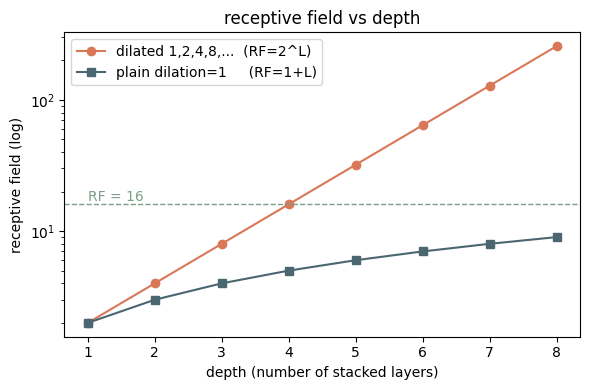

dilated RF by depth: [2, 4, 8, 16, 32, 64, 128, 256]
4 dilated layers reach RF = 16


In [6]:
depths = np.arange(1, 9)
rf_dilated = np.array([1 + sum((len(w2)-1) * (2**l) for l in range(L)) for L in depths])
rf_plain   = 1 + depths * (len(w2) - 1)

plt.figure(figsize=(6, 4))
plt.semilogy(depths, rf_dilated, 'o-', color='#d97757', label='dilated 1,2,4,8,...  (RF=2^L)')
plt.semilogy(depths, rf_plain,   's-', color='#4a6670', label='plain dilation=1     (RF=1+L)')
plt.axhline(16, color='#7b9e89', ls='--', lw=1)
plt.text(1, 17, 'RF = 16', color='#7b9e89')
plt.xlabel('depth (number of stacked layers)'); plt.ylabel('receptive field (log)')
plt.title('receptive field vs depth'); plt.legend(); plt.tight_layout(); plt.show()

print('dilated RF by depth:', rf_dilated.tolist())
print('4 dilated layers reach RF =', rf_dilated[3])

## Takeaway

- **Causal** conv = left-pad by $(K-1)d$ and read only current + past taps; length is preserved and the future never leaks back.
- A single dilated layer sees $(K-1)d+1$ inputs.
- **Stacking** doubling dilations makes the receptive field grow *exponentially* with depth ($2^L$ for $K=2$): four layers cover 16 steps — this is the WaveNet / TCN trick for long-range sequence modelling.